# Práctica 3 - Exploración de un dataset con pandas

## Objetivos

En esta práctica trabajarás con un dataset de clientes utilizando Python.

Al finalizar deberás ser capaz de:

- cargar datos desde un archivo CSV
- trabajar con un `DataFrame` de pandas
- identificar muestras y variables
- consultar la estructura de un dataset
- calcular estadísticas descriptivas
- seleccionar y filtrar datos
- analizar variables categóricas
- crear visualizaciones sencillas
- identificar las características \(X\) y la variable objetivo \(y\)
- determinar qué tipo de problema de Machine Learning podría resolverse

> **Importante:** no debes entrenar ningún modelo de Machine Learning en esta práctica.

## Contexto

Una empresa de telecomunicaciones quiere analizar el comportamiento de sus clientes. Dispone de información histórica y conoce qué clientes terminaron abandonando el servicio.

El objetivo futuro será desarrollar un sistema capaz de predecir:

> **¿Qué clientes tienen riesgo de abandonar la compañía?**

Para realizar la práctica utilizaremos el archivo `clientes.csv`.

| Variable | Descripción |
|---|---|
| `cliente_id` | Identificador del cliente |
| `edad` | Edad del cliente |
| `antiguedad` | Meses como cliente |
| `cuota_mensual` | Cuota mensual en euros |
| `consumo_datos` | Consumo mensual de datos en GB |
| `llamadas_soporte` | Número de llamadas a soporte |
| `incidencias` | Número de incidencias registradas |
| `tipo_contrato` | Mensual, anual o bienal |
| `satisfaccion` | Valoración del servicio de 1 a 5 |
| `abandono` | Indica si el cliente abandonó: Sí/No |

Cada fila corresponde a un cliente.

### Instrucciones

Completa las celdas de código marcadas con `# TODO`.

Cuando se solicite una interpretación, escribe tu respuesta en la celda Markdown correspondiente. No basta con ejecutar código: debes **interpretar los resultados**.

## Parte 1 - Preparación del entorno

### Ejercicio 1 - Importación

Importa NumPy, pandas y Matplotlib utilizando los alias convencionales.

In [66]:
# TODO: importa NumPy, pandas y matplotlib.pyplot
import numpy as np #Arrays y operaciones con mueros
import pandas as pd #Dataframes
import matplotlib.pyplot as plt # Graficos

### Respuesta

Explica brevemente para qué utilizaremos cada biblioteca:

- **NumPy:** trabaja con arrays y realiza operaciones matemáticas rápidas.
- **pandas:** carga, organiza y analiza datos en tablas (`DataFrame`).
- **Matplotlib:** crea gráficos (histogramas, barras, dispersión).

## Parte 2 - Carga e inspección inicial

### Ejercicio 2 - Cargar el dataset

Carga `clientes.csv` en un DataFrame denominado `df` y muestra sus primeras filas.

In [67]:
# TODO: carga el archivo clientes.csv en df
df = pd.read_csv('clientes.csv')
# TODO: muestra las primeras filas
df.head()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,tipo_contrato,satisfaccion,abandono
0,10001,23,61.0,32.16,11.9,1,2,Mensual,1,No
1,10002,62,79.0,45.71,17.4,2,0,Anual,2,No
2,10003,55,49.0,60.48,14.6,0,1,Mensual,5,No
3,10004,43,6.0,116.82,21.8,4,0,Anual,3,No
4,10005,43,70.0,36.13,8.8,2,2,Anual,1,Sí


### Respuesta

**¿Qué representa cada fila del DataFrame?**

Cada fila es una muestra: un cliente con todos sus datos.

**¿Qué representa cada columna?**

Cada columna es una variable (una característica de los clientes, como `edad` o `abandono`).

### Ejercicio 3 - Dimensiones

Obtén mediante código las dimensiones del dataset.

In [68]:
# TODO: muestra las dimensiones del DataFrame
df.shape

(180, 10)

### Respuesta

- **Número de muestras:** 180
- **Número de variables:** 10

### Ejercicio 4 - Columnas

Obtén mediante código los nombres de todas las columnas.

In [69]:
# TODO: muestra los nombres de las columnas
df.columns

Index(['cliente_id', 'edad', 'antiguedad', 'cuota_mensual', 'consumo_datos',
       'llamadas_soporte', 'incidencias', 'tipo_contrato', 'satisfaccion',
       'abandono'],
      dtype='str')

### Respuesta

**¿Qué columna parece representar la variable que queremos predecir? ¿Por qué?**

`abandono`, porque es lo que la empresa quiere predecir (si el cliente se va o no). Es la variable objetivo y su tipo es clasificación.

### Ejercicio 5 - Tipos de datos

Obtén los tipos de datos de todas las columnas.

In [70]:
# TODO: consulta los tipos de datos
df.dtypes

cliente_id            int64
edad                  int64
antiguedad          float64
cuota_mensual       float64
consumo_datos       float64
llamadas_soporte      int64
incidencias           int64
tipo_contrato           str
satisfaccion          int64
abandono                str
dtype: object

### Respuesta

**Variables numéricas:**

`edad`, `antiguedad`, `cuota_mensual`, `consumo_datos`, `llamadas_soporte`, `incidencias` y `satisfaccion` (tipos `int` y `float`).

**Variables categóricas:**

`tipo_contrato` y `abandono` (texto). `cliente_id` es solo un identificador.

**¿`cliente_id` debería considerarse una característica numérica simplemente porque contiene números? Razona la respuesta.**

No. Es una etiqueta que identifica al cliente: sumarla o promediarla no tiene sentido y no describe su comportamiento.

## Parte 3 - Estructura y calidad inicial

### Ejercicio 6 - Información general

Utiliza `info()` para analizar la estructura del dataset.

In [71]:
# TODO: muestra la información general del DataFrame

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        180 non-null    int64  
 1   edad              180 non-null    int64  
 2   antiguedad        178 non-null    float64
 3   cuota_mensual     180 non-null    float64
 4   consumo_datos     179 non-null    float64
 5   llamadas_soporte  180 non-null    int64  
 6   incidencias       180 non-null    int64  
 7   tipo_contrato     180 non-null    str    
 8   satisfaccion      180 non-null    int64  
 9   abandono          180 non-null    str    
dtypes: float64(3), int64(5), str(2)
memory usage: 14.2 KB


### Respuesta

- ¿Cuántas entradas contiene?

180 entradas (filas) y 10 columnas.

- ¿Qué tipos de datos aparecen?

`int64` (enteros), `float64` (decimales) y `str` (texto).

- ¿Todas las columnas contienen el mismo número de valores no nulos?

No. La mayoría tiene 180, pero `antiguedad` tiene 178 y `consumo_datos` tiene 179.

- ¿Parece existir algún valor ausente?

Sí: 2 en `antiguedad` y 1 en `consumo_datos`.

- ¿Cómo puedes deducirlo a partir de `info()`?

Comparando `Non-Null Count` de cada columna con el total de entradas (180): si es menor, faltan valores.

## Parte 4 - Estadística descriptiva

### Ejercicio 7 - Descripción estadística

Obtén las estadísticas descriptivas de las variables numéricas.

In [72]:
# TODO: genera las estadísticas descriptivas
df.describe()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,satisfaccion
count,180.000000,180.000000,178.000000,180.000000,179.000000,180.000000,180.000000,180.000000
mean,10090.500000,47.283333,62.050562,71.185667,16.408380,1.705556,1.111111,3.016667
std,52.105662,15.929059,33.991071,29.279251,9.813719,1.249345,1.082563,1.423957
min,10001.000000,18.000000,1.000000,20.480000,1.200000,0.000000,0.000000,1.000000
25%,10045.750000,34.000000,34.000000,43.172500,9.800000,1.000000,0.000000,2.000000
50%,10090.500000,47.000000,61.000000,72.690000,14.300000,1.000000,1.000000,3.000000
75%,10135.250000,62.000000,91.750000,97.177500,20.400000,2.250000,2.000000,4.000000
max,10180.000000,75.000000,120.000000,119.440000,54.200000,6.000000,5.000000,5.000000


### Interpretación

A partir del resultado, indica:

- edad media: 47,28 años
- edad mínima: 18
- edad máxima: 75
- cuota mensual media: 71,19 €
- cuota mensual máxima: 119,44 €
- media de llamadas a soporte: 1,71
- media de incidencias: 1,11
- satisfacción media: 3,02

**Interpretación:** los clientes son adultos de edad media (47 años, entre 18 y 75). Pagan de media unos 71 € al mes, con mucha variación (de 20 a 119 €). Llaman poco a soporte (menos de 2 veces) y tienen pocas incidencias (alrededor de 1). La satisfacción es intermedia (3 sobre 5), así que no hay una opinión claramente buena ni mala.

### Ejercicio 8 - Cálculos individuales

Calcula mediante instrucciones independientes los valores solicitados.

In [73]:
# TODO: media de edad
print(df['edad'].mean())

# TODO: mediana de edad
print(df['edad'].median())

# TODO: cuota mínima
print(df['cuota_mensual'].min())

# TODO: cuota máxima
print(df['cuota_mensual'].max())

# TODO: número total de incidencias
# sale 180, queremos saber numero de incidencias totales 
print(df['incidencias'].count())
#este de abajo es el bueno para contar
print(df['incidencias'].sum())

# TODO: satisfacción media
print(df['satisfaccion'].mean())

#curiosidad para dejarlo bonito esta el print(f"(df....):.3f") //// el f y :.3f sirve para dejar 3 decimales (no aporta nada)

47.28333333333333
47.0
20.48
119.44
180
200
3.0166666666666666


### Comprobación

¿Coinciden estos resultados con los obtenidos mediante `describe()` cuando corresponde?

Sí: la media de edad (47,28), la cuota mínima (20,48), la máxima (119,44) y la satisfacción media (3,02) coinciden con `describe()`. La mediana de edad (47) coincide con el 50 %. El total de incidencias (200) no aparece en `describe()`, porque allí solo se ve la media (1,11 × 180 ≈ 200).

## Parte 5 - Selección de información

### Ejercicio 9 - Selección de columnas

Crea un DataFrame `df_clientes` que contenga únicamente `edad`, `antiguedad`, `cuota_mensual`, `satisfaccion` y `abandono`. Muestra sus primeras cinco filas.

In [74]:
# TODO: crea df_clientes
#lo de filtro es opcional, se puede poner con doble corchete despues de df 
filtro  = ['edad', 'antiguedad', 'cuota_mensual', 'satisfaccion', 'abandono']
df_clientes = df[filtro]

# TODO: muestra las primeras cinco filas
df_clientes.head()

,edad,antiguedad,cuota_mensual,satisfaccion,abandono
0,23,61.0,32.16,1,No
1,62,79.0,45.71,2,No
2,55,49.0,60.48,5,No
3,43,6.0,116.82,3,No
4,43,70.0,36.13,1,Sí


### Respuesta

**¿Sigue representando cada fila al mismo cliente que en el DataFrame original? Explica por qué.**

Sí. Solo hemos quitado columnas, no filas, así que cada fila sigue siendo el mismo cliente, aunque con menos datos.

## Parte 6 - Filtrado

### Ejercicio 10 - Clientes por edad

Obtén todos los clientes mayores de 50 años y calcula cuántos cumplen la condición.

In [ ]:
# TODO: filtra los clientes mayores de 50 años
result = df['edad']>50
print(result)
print()
print()
print()

# TODO: calcula cuántos son
#logica de lo de los dos corchetes, es como lo de arriba de la practica 9, es la parte del filtro
mayores_50 = df[df['edad']>50]
print(mayores_50)
print('Clientes mayores de 50:', len(mayores_50))

### Ejercicio 11 - Clientes con incidencias

Selecciona los clientes que tengan `incidencias > 0` y determina cuántos son.

In [ ]:
# TODO: filtra los clientes con incidencias
filtro= df['incidencias']>0
print (filtro)
df_incidencias = df[filtro]
columnas = ['cliente_id', 'incidencias', 'satisfaccion']
print(df_incidencias[columnas])

# TODO: calcula cuántos son
print ("clientes con incidencias: ", len(df_incidencias))

### Ejercicio 12 - Condiciones combinadas

Obtén los clientes que cumplan simultáneamente:

$$
edad < 30
$$

y

$$
llamadas\_soporte \geq 3
$$

Muestra únicamente `cliente_id`, `edad`, `llamadas_soporte` y `abandono`.

In [ ]:
# TODO: realiza el filtro y muestra únicamente las columnas solicitadas
filtro = (df['edad']< 30) & (df['llamadas_soporte']>=3)
df_ej12 = df[filtro]
columnas = ['cliente_id', 'edad', 'llamadas_soporte', 'abandono']
print(df_ej12[columnas])


### Respuesta

**¿Qué operador has utilizado para combinar ambas condiciones?**

El operador `&` (AND), que exige que se cumplan las dos condiciones a la vez. Cada condición va entre paréntesis.

### Ejercicio 13 - Segundo filtro combinado

Localiza clientes que cumplan:

$$
satisfaccion \leq 2
$$

y

$$
incidencias \geq 2
$$

Muestra las filas encontradas.

In [ ]:
# TODO: realiza el filtro
filtro = (df['satisfaccion']<=2) & (df['incidencias']>=2)
df_ej13 = df[filtro]
columnas = ['cliente_id', 'incidencias', 'satisfaccion', 'abandono']
print(df_ej13[columnas])
print ("clientes con estas caracteristicas: ", len(df_ej13))

     cliente_id  incidencias  satisfaccion abandono
0         10001            2             1       No
4         10005            2             1       Sí
5         10006            2             2       No
11        10012            5             1       Sí
19        10020            2             1       No
20        10021            2             2       Sí
24        10025            2             1       Sí
25        10026            2             2       Sí
35        10036            2             1       Sí
44        10045            2             1       No
46        10047            4             2       Sí
50        10051            2             2       No
59        10060            3             2       Sí
61        10062            2             1       No
62        10063            4             2       Sí
65        10066            2             1       Sí
67        10068            3             1       Sí
89        10090            2             2       Sí
104       10

### Reflexión

**Observando únicamente estos resultados, ¿podemos afirmar que una satisfacción baja provoca el abandono?**

Justifica tu respuesta.

No. Solo vemos que muchos de estos clientes abandonaron (la mayoría), pero eso es una relación, no una prueba de causa. Pueden influir otros factores (cuota, contrato, incidencias) y no hemos comparado con los clientes satisfechos.

## Parte 7 - Variables categóricas

### Ejercicio 14 - Tipo de contrato

Obtén los diferentes valores de `tipo_contrato` y calcula cuántos clientes pertenecen a cada categoría.

In [ ]:
# TODO: muestra las categorías existentes

print(df['tipo_contrato'].unique())
print()

# TODO: calcula la frecuencia de cada categoría
print(df['tipo_contrato'].value_counts())

<StringArray>
['Mensual', 'Anual', 'Bienal']
Length: 3, dtype: str

tipo_contrato
Mensual    94
Anual      56
Bienal     30
Name: count, dtype: int64


### Respuesta

**¿Cuál es el tipo de contrato más frecuente?**

`Mensual`, con 94 clientes (frente a 56 `Anual` y 30 `Bienal`).

### Ejercicio 15 - Variable `abandono`

Obtén las categorías existentes, el número de clientes de cada categoría y sus frecuencias relativas.

In [ ]:
# TODO: categorías existentes
from locale import normalize


print(df['abandono'].unique())
print()
# TODO: frecuencias absolutas
print(df['abandono'].value_counts())
print()
# TODO: frecuencias relativas
print(df['abandono'].value_counts(normalize=True))

<StringArray>
['No', 'Sí']
Length: 2, dtype: str

abandono
No    110
Sí     70
Name: count, dtype: int64

abandono
No    0.611111
Sí    0.388889
Name: proportion, dtype: float64


### Interpretación

Expresa las frecuencias relativas mediante porcentajes y redacta una breve conclusión sobre la distribución de `abandono`.

- No abandonan: 61,1 % (110 clientes)
- Abandonan: 38,9 % (70 clientes)

**Conclusión:** la mayoría de clientes se queda, pero casi 4 de cada 10 abandonan. Las clases están algo desbalanceadas (61/39), aunque no de forma extrema.

## Parte 8 - Visualización

Todos los gráficos deben contener como mínimo:

- título;
- etiquetas de los ejes cuando correspondan;
- una representación clara.

### Ejercicio 16 - Distribución de edad

Construye un histograma de `edad`.

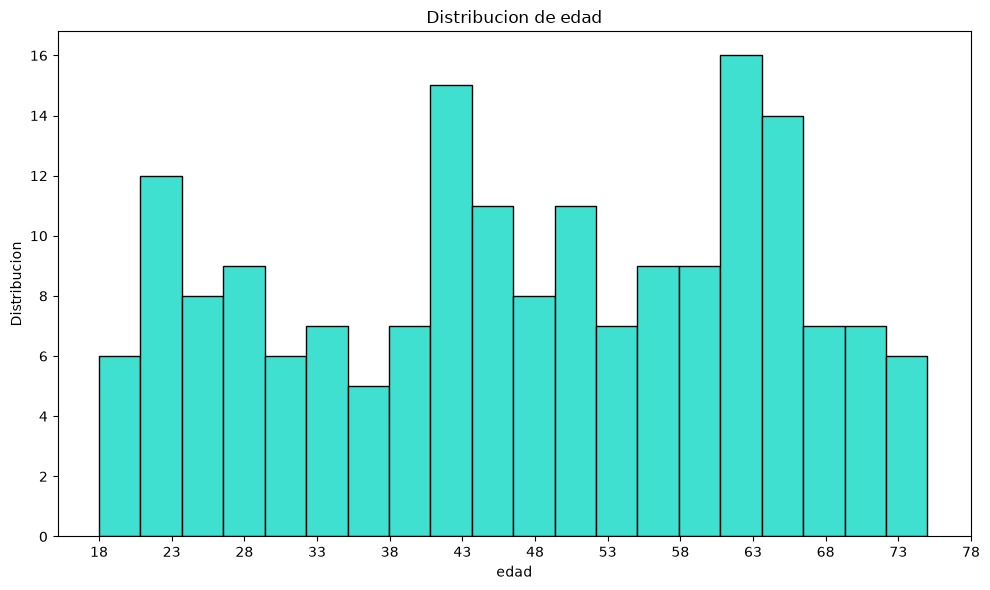

In [93]:
# TODO: crea el histograma de edad
plt.figure(figsize=(10,6)) #8*4 pulgadas / tamaño de la figura
plt.hist(df['edad'], bins=20, color='turquoise', edgecolor='black')
plt.xticks(range(18,80,5))
plt.xlabel("edad")
plt.ylabel("Distribucion")
plt.title("Distribucion de edad")
plt.tight_layout()
plt.show()

### Interpretación

**¿Qué información proporciona un histograma que no resulta tan fácil obtener observando directamente las filas del DataFrame?**

Muestra cómo se distribuyen los datos: qué edades son más frecuentes, dónde se concentran los clientes y si hay huecos. En las filas esto es difícil de ver. Aquí hay picos alrededor de 43 y 62 años, sin una forma concentrada en un único valor.

### Ejercicio 17 - Abandono

Representa mediante un gráfico de barras el número de clientes que abandonaron y que no abandonaron.

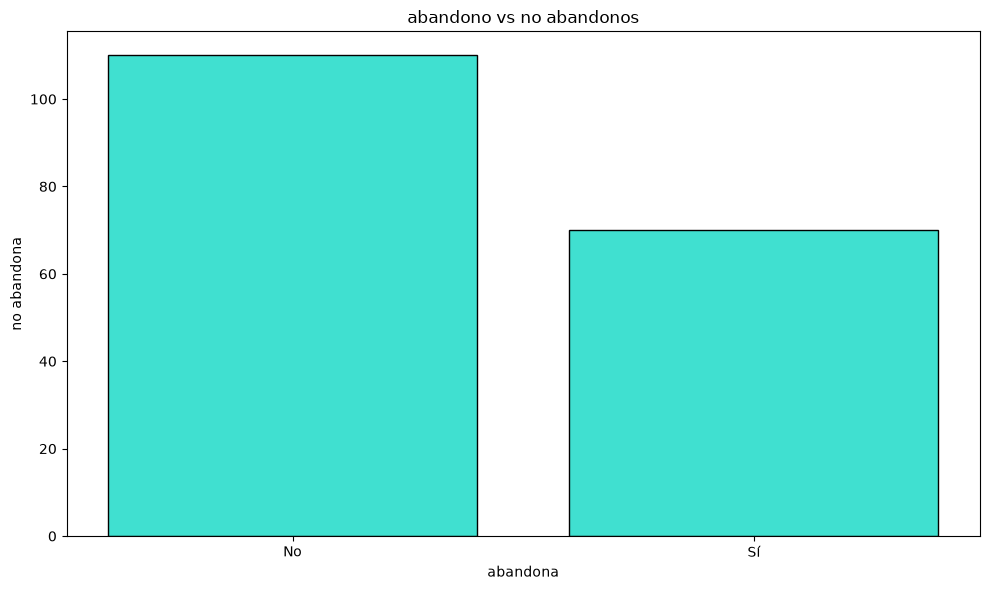

In [99]:
# TODO: crea el gráfico de barras
n_abandonos = df['abandono'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(n_abandonos.index, n_abandonos.values, color='turquoise', edgecolor='black')#bar para barras
plt.xlabel('abandona')
plt.ylabel('no abandona')
plt.title('abandono vs no abandonos')
plt.tight_layout()


### Interpretación

Describe brevemente qué muestra el gráfico.

Compara el número de clientes que no abandonan (110) con los que abandonan (70). La barra de "No" es más alta, pero la de "Sí" es bastante grande.

> Nota: en el código, las etiquetas de los ejes están cambiadas. Lo correcto sería `xlabel('Abandono')` y `ylabel('Número de clientes')`.

### Ejercicio 18 - Cuota mensual

Crea un histograma para `cuota_mensual`.

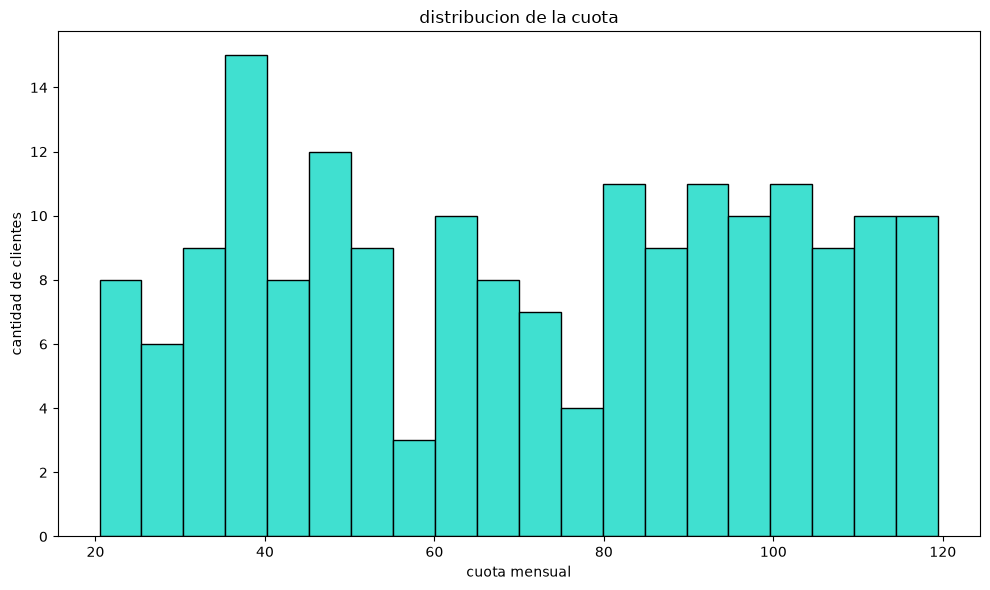

In [ ]:
# TODO: crea el histograma de cuota_mensual

plt.figure(figsize=(10,6)) #8*4 pulgadas / tamaño de la figura
plt.hist(df['cuota_mensual'], bins=20, color='turquoise', edgecolor='black')
plt.xlabel('cuota mensual')
plt.ylabel('cantidad de clientes')
plt.title('distribucion de la cuota')
plt.tight_layout()


### Interpretación

Analiza visualmente la distribución.

Las cuotas están repartidas entre 20 € y 120 €, sin una forma de campana. Hay un pico entre 35 y 40 € y muchos clientes con cuotas altas (80-120 €). Así hay dos grupos: clientes con cuotas bajas y clientes con cuotas altas.

### Ejercicio 19 - Edad y cuota

Crea un diagrama de dispersión utilizando:

$$
x = edad
$$

$$
y = cuota\_mensual
$$

Text(0, 0.5, 'cuota_mensual')

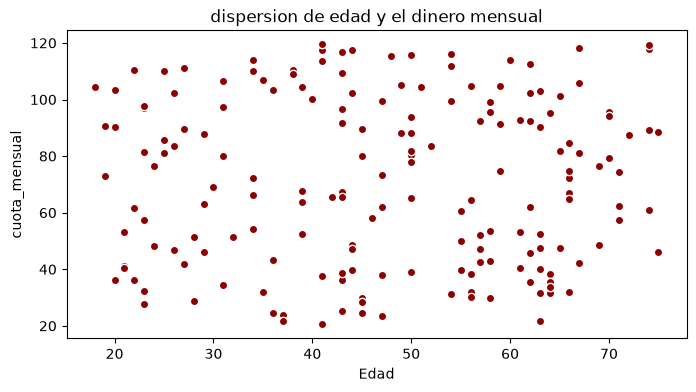

In [ ]:
# TODO: crea el diagrama de dispersión



plt.figure(figsize=(8,4)) #8*4 pulgadas / tamaño de la figura
plt.scatter(df['edad'], df['cuota_mensual'],color='darkred',edgecolors='white')
plt.title('dispersion de edad y el dinero mensual')
plt.xlabel('Edad')
plt.ylabel('cuota_mensual')

### Interpretación

- ¿Qué representa cada punto?

Un cliente: su edad (eje x) y su cuota mensual (eje y).

- ¿Observas a simple vista alguna relación clara entre ambas variables?

No. Los puntos están dispersos por todo el gráfico: hay jóvenes y mayores con cuotas altas y bajas, así que la edad no parece determinar la cuota.

## Parte 9 - Identificación de $X$ e $y$

La empresa quiere construir en el futuro un modelo que determine si un cliente abandonará.

### Ejercicio 20 - Variable objetivo

Identifica y crea `y`. Después muestra sus cinco primeros valores.

In [110]:
# TODO: crea y
y= df['abandono']

# TODO: muestra sus cinco primeros valores
y.head()

0    No
1    No
2    No
3    No
4    Sí
Name: abandono, dtype: str

### Respuesta

**¿Por qué esta variable corresponde a \(y\)?**

Porque es lo que queremos predecir (si el cliente abandona o no) y ya conocemos su valor en los datos históricos, lo que permite que el modelo aprenda.

### Ejercicio 21 - Características

Crea `X` utilizando inicialmente estas características:

- `edad`
- `antiguedad`
- `cuota_mensual`
- `consumo_datos`
- `llamadas_soporte`
- `incidencias`
- `tipo_contrato`
- `satisfaccion`

Después comprueba sus dimensiones.

In [ ]:
# TODO: crea X
X = df[[
'edad',
'antiguedad', 
'cuota_mensual',
'consumo_datos',
'llamadas_soporte',
'incidencias',
'tipo_contrato',
'satisfaccion']]

# TODO: muestra las dimensiones de X
print(X.shape)

### Respuesta

Si el dataset contiene \(n\) clientes, esperamos:

\[
X.shape = (n,\ ?)
\]

**¿Qué número debe aparecer en `?`? ¿Por qué?**

El 8, porque hemos elegido 8 características (columnas). Con nuestros datos, `X.shape = (180, 8)`.

## Parte 10 - Razonamiento de Machine Learning

### Ejercicio 22 - Identificación del problema

Queremos predecir:

`abandono → Sí / No`

Responde razonadamente:

1. ¿Estamos ante aprendizaje supervisado o no supervisado?
2. ¿Por qué?
3. ¿Es clasificación o regresión?
4. ¿Por qué?
5. ¿Es clasificación binaria o multiclase?
6. ¿Cuáles son las clases?

### Respuesta

1. **Aprendizaje supervisado.**
2. Porque los datos históricos ya incluyen la respuesta correcta (`abandono`), y el modelo aprende de ella.
3. **Clasificación.**
4. Porque lo que predecimos es una categoría (Sí/No), no un número continuo.
5. **Binaria**, porque hay solo dos posibles resultados.
6. Las clases son `Sí` (abandona) y `No` (no abandona).

## Parte 11 - Un cambio en el problema

Supongamos ahora que la empresa plantea:

> Queremos predecir cuál será el **consumo de datos del próximo mes** de cada cliente.

### Ejercicio 23

Responde:

1. ¿Cuál sería ahora la variable objetivo?
2. ¿Seguiríamos teniendo exactamente el mismo \(X\)?
3. ¿Sería clasificación o regresión?
4. ¿Seguiría siendo aprendizaje supervisado?
5. Justifica cada respuesta.

### Respuesta

1. **`consumo_datos`** (el consumo del próximo mes), porque es lo que queremos predecir.
2. **No.** `consumo_datos` pasaría a ser `y`, así que saldría de `X`; y `abandono` podría entrar como característica.
3. **Regresión**, porque el consumo es un valor numérico continuo (GB).
4. **Sí**, porque conocemos el valor real de la variable objetivo en los datos con los que se entrena.

### Respuesta

No lo utilizaría. Es solo un número que identifica al cliente y no describe su comportamiento. Si se usara, el modelo podría encontrar relaciones sin sentido (por ejemplo, que los ids altos abandonan más) que no sirven para clientes nuevos. Además, un id es un número arbitrario: ser mayor o menor no significa nada.

### Respuesta

No estamos preparados. Antes de entrenar habría que:

1. **Tratar los valores ausentes** en `antiguedad` y `consumo_datos`.
2. **Convertir las variables categóricas** (`tipo_contrato`) a números, porque el modelo necesita datos numéricos.
3. **Separar los datos en entrenamiento y prueba**, para evaluar el modelo con datos que no ha visto.
4. **Revisar el desbalance** de `abandono` (61 % / 39 %) y los valores atípicos (por ejemplo, un consumo de 54 GB).
5. **Escalar las variables** si el modelo lo necesita.

### Conclusiones

El dataset tiene 180 clientes (filas) y 10 variables (columnas). Hay 7 variables numéricas, 2 categóricas (`tipo_contrato` y `abandono`) y un identificador (`cliente_id`). Faltan 2 valores en `antiguedad` y 1 en `consumo_datos`. Respecto a `abandono`, el 61,1 % de los clientes se queda y el 38,9 % se va, con una ligera diferencia entre clases. Las estadísticas muestran una edad media de 47 años, una cuota mensual media de 71 € y una satisfacción media de 3 sobre 5. Los gráficos muestran que la edad y la cuota están repartidas sin una forma de campana y que no hay una relación clara entre ellas. La variable objetivo es `y = abandono`, y `X` contiene las 8 características restantes, sin el identificador. Es un problema de aprendizaje supervisado, de clasificación binaria (Sí/No). Antes de entrenar hay que tratar los valores ausentes, convertir `tipo_contrato` a números, dividir en entrenamiento y prueba y revisar el desbalance y los valores atípicos.

---

# Ampliación opcional

Si terminas antes, investiga cómo obtener con pandas:

1. El número exacto de valores ausentes de cada columna.
2. El número de clientes agrupados por `tipo_contrato` y `abandono`.
3. La cuota mensual media de quienes abandonaron y de quienes no.
4. La satisfacción media de ambos grupos.

No utilices algoritmos de Machine Learning.

In [ ]:
# AMPLIACIÓN OPCIONAL

# 1. Valores ausentes por columna
print(df.isnull().sum())

# 2. Clientes agrupados por tipo_contrato y abandono
print(df.groupby(['tipo_contrato', 'abandono']).size())

# 3. Cuota mensual media según abandono
print(df.groupby('abandono')['cuota_mensual'].mean())

# 4. Satisfacción media según abandono
print(df.groupby('abandono')['satisfaccion'].mean())

# Antes de entregar

Comprueba que:

- has completado todas las celdas `TODO`
- has respondido las preguntas en Markdown
- todos los gráficos tienen título y etiquetas
- has reiniciado el entorno y ejecutado el notebook completo desde el principio
- no se producen errores
- no has entrenado ningún modelo

**Nombre recomendado del archivo de entrega:**

`Practica_03_Apellido_Nombre.ipynb`